### RaschPy RSM worked example

This notebook works through a sample Rasch analysis of a simulated data set (1,000 persons, 8 items with a maximum score of 5, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.RSM_Sim(no_of_items=8, no_of_persons=80, max_score=4, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
responses_disconnected.iloc[:40, 4:] = float('nan')   # first 40 persons: only answer items 1-4
responses_disconnected.iloc[40:, :4] = float('nan')    # last 40 persons: only answer items 5-8

broken_rsm = rp.RSM(responses_disconnected, max_score=4)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/rsm.py:207: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_52513/2776287308.py:6: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_rsm = rp.RSM(responses_disconnected, max_score=4)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_rsm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': []}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=42` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set.

In [4]:
sim = rp.RSM_Sim(no_of_items=8, no_of_persons=1000, max_score=5, missing=0, seed=42)
sim.responses.to_csv('rsm_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_rsm()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_rsm('rsm_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
Person_1,0.0,5.0,3.0,5.0,5.0,5.0,2.0,1.0
Person_2,0.0,2.0,1.0,0.0,0.0,2.0,0.0,0.0


Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8


Create an RSM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `rsm.generating`, which lets us check parameter recovery further down, and also means `max_score` doesn't need to be supplied again. If you're analysing your own data, pass a DataFrame and `max_score` instead (e.g. `rp.RSM(data, max_score)`).

In [8]:
rsm = rp.RSM(sim)

Generate item estimates. The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
rsm.calibrate()

CPU times: user 1.06 ms, sys: 203 μs, total: 1.27 ms
Wall time: 1.15 ms


Check the item location estimates - view the first two items

In [10]:
rsm.items.head(2)

Item_1    1.022239
Item_2   -0.485495
dtype: float64

Since this is simulated data, we know the true generating item locations and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery — alongside the Pearson correlation, SD ratio, regression coefficient, and RMSE:

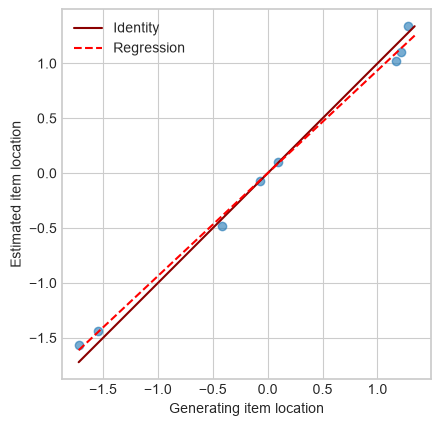

item location Pearson correlation:              0.998
item location SD ratio (estimated / generating): 0.939
item location regression coefficient:            0.937
item location RMSE:                              0.099


In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')

recovery_plot(sim.items, rsm.items, 'item location', 'my_rsm_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [12]:
%%time
rsm.item_stats_df()
rsm.item_stats.to_csv('rsm_item_stats.csv')

CPU times: user 655 ms, sys: 21.1 ms, total: 676 ms
Wall time: 678 ms


Check the item statistics table - view the first two items

In [13]:
rsm.item_stats.head(2)

,Estimate,SE,Count,Facility,Infit MS,Outfit MS
Item_1,1.022,0.068,1000,0.285,0.796,0.790
Item_2,-0.485,0.064,1000,0.581,0.857,0.869


Generate a table of threshold statistics (and check run time), and save to file

In [14]:
%%time
rsm.threshold_stats_df()
rsm.threshold_stats.to_csv('rsm_threshold_stats.csv')

CPU times: user 1.15 ms, sys: 551 μs, total: 1.7 ms
Wall time: 1.37 ms


Check the threshold statistics table - view the first two thresholds

In [15]:
rsm.threshold_stats.head(2)

,Estimate,SE,Infit MS,Outfit MS
Threshold 1,-1.377,0.082,0.950,0.922
Threshold 2,-0.104,0.064,0.948,0.936


And the same recovery check for the shared threshold vector, against `sim.thresholds`:

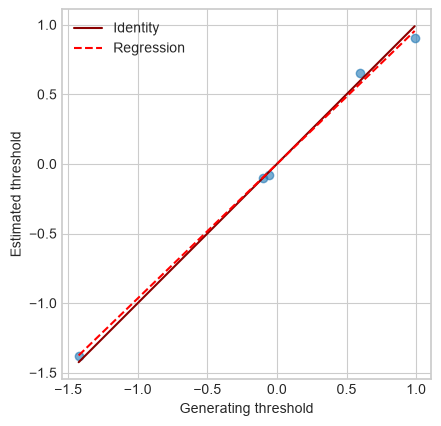

threshold Pearson correlation:              0.998
threshold SD ratio (estimated / generating): 0.967
threshold regression coefficient:            0.966
threshold RMSE:                              0.053


In [16]:
recovery_plot(sim.thresholds, rsm.thresholds, 'threshold', 'my_rsm_threshold_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [17]:
%%time
rsm.person_stats_df()
rsm.person_stats.to_csv('rsm_person_stats.csv')

CPU times: user 5.35 ms, sys: 787 μs, total: 6.14 ms
Wall time: 5.92 ms


Check the person statistics table - view the first two items

In [18]:
rsm.person_stats.head(2)

,Estimate,CSEM,Score,Max score,p,Infit MS,Infit Z,Outfit MS,Outfit Z
Person_1,0.751,0.343,26,40,0.650,1.005,0.183,0.822,-0.118
Person_2,-1.986,0.470,5,40,0.125,1.047,0.293,0.801,-0.045


And the same recovery check for person locations, against `sim.persons`:

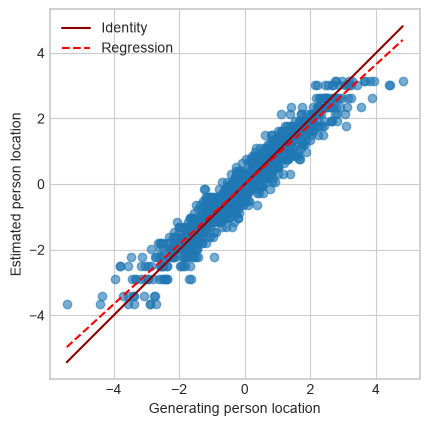

person location Pearson correlation:              0.962
person location SD ratio (estimated / generating): 0.95
person location regression coefficient:            0.914
person location RMSE:                              0.405


In [19]:
recovery_plot(sim.persons, rsm.persons, 'person location', 'my_rsm_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [20]:
%%time
rsm.test_stats_df()
rsm.test_stats.to_csv('rsm_test_stats.csv')

CPU times: user 843 μs, sys: 743 μs, total: 1.59 ms
Wall time: 1.13 ms


Check the test statistics table

In [21]:
rsm.test_stats

,Items,Persons
Mean,-0.000,-0.005
SD,1.123,1.410
Separation ratio,15.840,3.821
Strata,21.453,5.429
Reliability,0.996,0.936


Run a residual correlation analysis (and check run time), and save relevant output to file

In [22]:
%%time
rsm.res_corr_analysis()
rsm.residual_correlations.to_csv('rsm_residual_correlations.csv')
rsm.loadings.to_csv('rsm_loadings.csv')

CPU times: user 5.48 ms, sys: 1.65 ms, total: 7.13 ms
Wall time: 7.67 ms


View the table of pairwise standard residual correlations

In [23]:
rsm.residual_correlations

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
Item_1,1.000000,-0.119200,-0.148736,-0.172818,-0.127145,-0.068074,-0.219246,-0.109558
Item_2,-0.119200,1.000000,-0.120288,-0.168574,-0.177820,-0.175239,-0.157206,-0.197805
Item_3,-0.148736,-0.120288,1.000000,-0.167959,-0.119770,-0.185138,-0.141015,-0.183878
Item_4,-0.172818,-0.168574,-0.167959,1.000000,-0.138029,-0.110166,-0.162480,-0.165827
Item_5,-0.127145,-0.177820,-0.119770,-0.138029,1.000000,-0.200770,-0.069182,-0.036260
Item_6,-0.068074,-0.175239,-0.185138,-0.110166,-0.200770,1.000000,-0.061025,-0.063010
Item_7,-0.219246,-0.157206,-0.141015,-0.162480,-0.069182,-0.061025,1.000000,-0.159630
Item_8,-0.109558,-0.197805,-0.183878,-0.165827,-0.036260,-0.063010,-0.159630,1.000000


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [24]:
rsm.loadings['PC 1']

Item_1   -0.025544
Item_2    0.291608
Item_3    0.175484
Item_4    0.046481
Item_5   -0.123613
Item_6   -0.129946
Item_7   -0.023949
Item_8   -0.279204
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) for Item 2, with observed category means plotted and the central item location marked

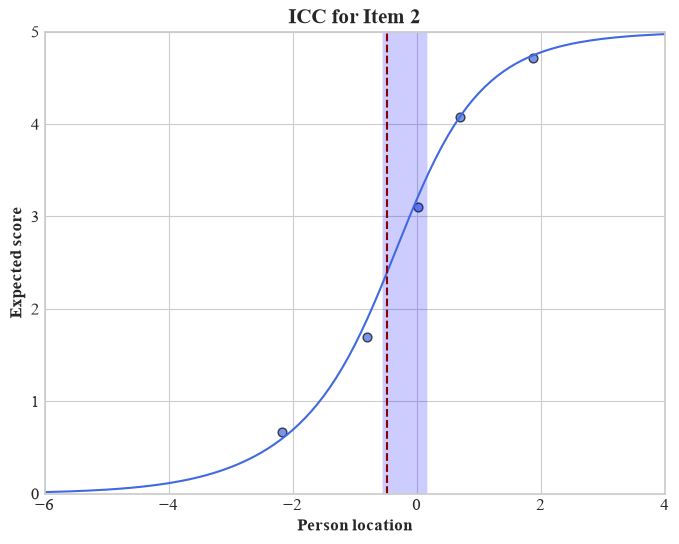

In [25]:
rsm.icc('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-6, xmax=4, filename='my_rsm_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

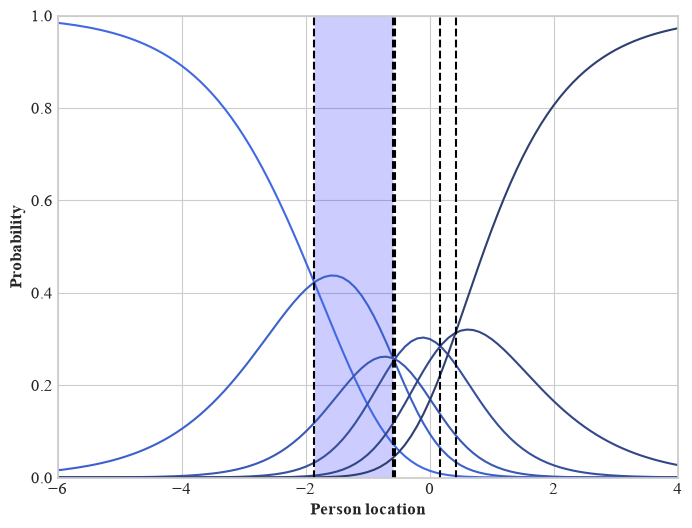

In [26]:
rsm.crcs('Item_2', thresh_lines=True, cat_highlight=1, xmin=-6, xmax=4, filename='my_rsm_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

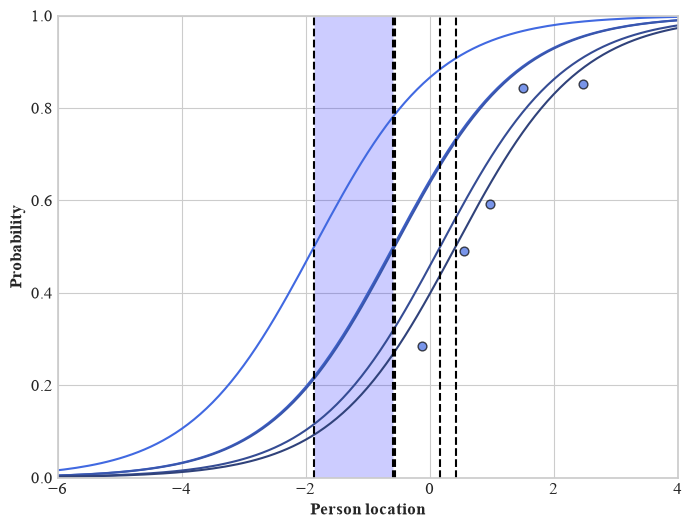

In [27]:
rsm.threshold_ccs('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-6, xmax=4, filename='my_rsm_threshold_ccs')

Produce an item information function curve for Item 2

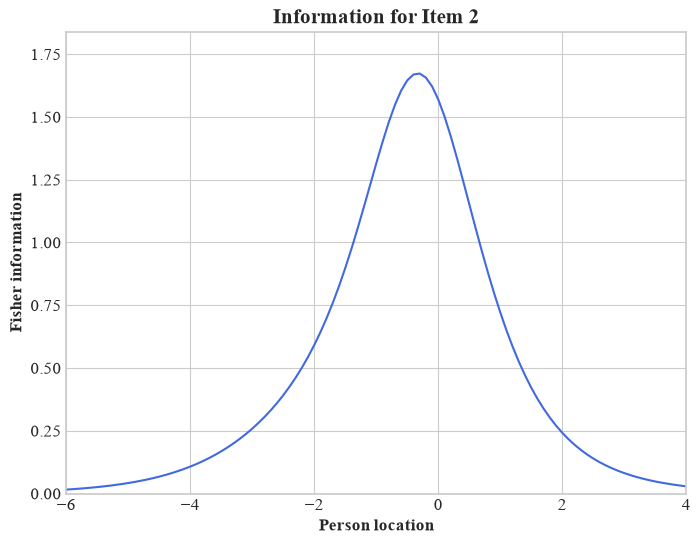

In [28]:
rsm.iic('Item_2', title='Information for Item 2', xmin=-6, xmax=4, filename='my_rsm_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 20 and 30 plotted.

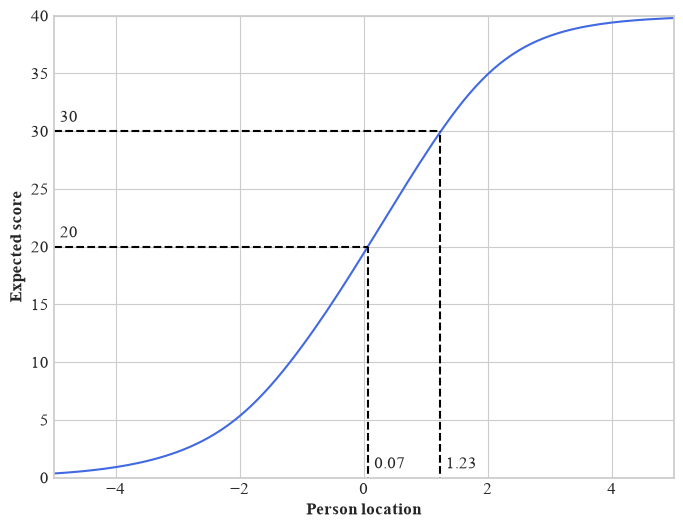

In [29]:
rsm.tcc(score_lines=[20, 30], score_labels=True, filename='my_rsm_tcc')

Produce a test information curve

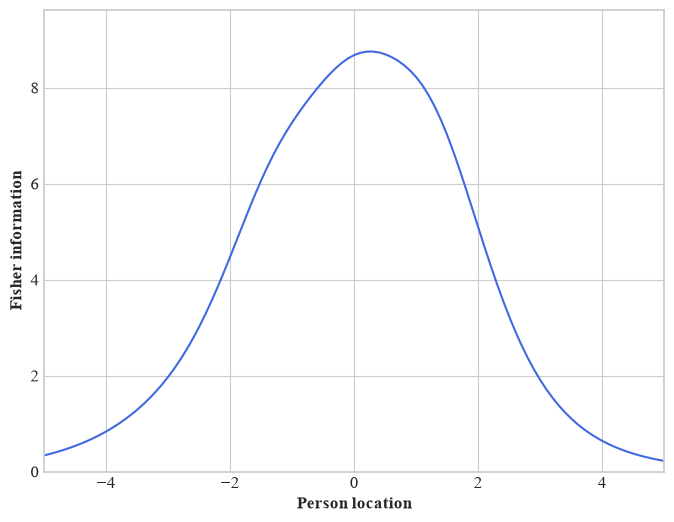

In [30]:
rsm.test_info(filename='my_rsm_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

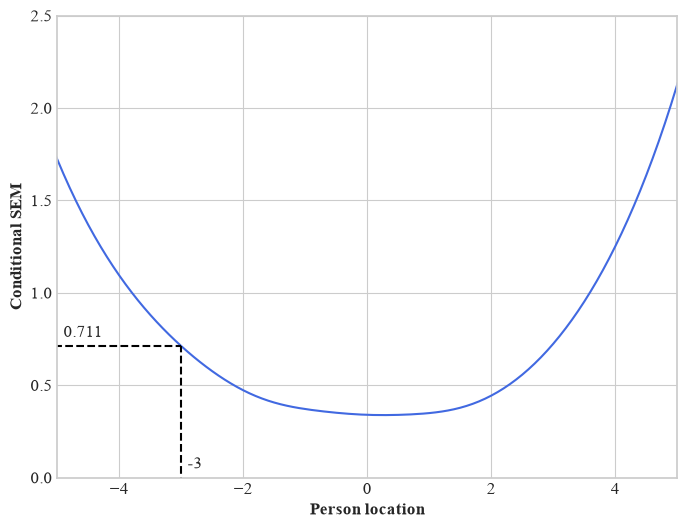

In [31]:
rsm.test_csem(point_csem_lines=[-3], point_csem_labels=True, ymax=2.5, filename='my_rsm_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

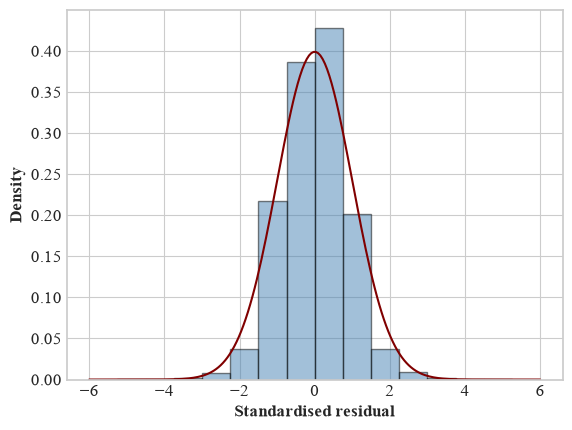

In [32]:
rsm.std_residuals_plot(bin_width=0.6, normal=True, filename='my_rsm_std_residuals_plot')